In [1]:
from dotenv import load_dotenv
import os
load_dotenv()
if os.environ["GOOGLE_API_KEY"]=="" :
    raise ValueError("Please set the GOOGLE_API_KEY environment variable in the .env file.")
else:
    print("GOOGLE_API_KEY is set.")

GOOGLE_API_KEY is set.


In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAI
llm=ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",  # or "gemini-1.0-pro", "gemini-2.0-flash", etc.
    temperature=1.0,  # Gemini 3.0+ defaults to 1.0
    max_tokens=None,
    timeout=None,
    max_retries=2,
    # other params...
)

llm



ChatGoogleGenerativeAI(output_version=None, profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-2.5-flash', temperature=1.0, max_retries=2, client=<google.genai.client.Client object at 0x0000011A337A1940>, default_metadata=(), model_kwargs={})

## **Pydantic Schema**

In [3]:
from pydantic import BaseModel, Field

class graph_schema(BaseModel):
    topic: str = Field(description="The topic of the conversation")
    post: str = Field(description="The post content")
    curated_post: str = Field(description="The curated post content ")

demo_obj = graph_schema(topic="The importance of data privacy in digital age", 
                        post="Data Privacy is crucial in today's digital world. WIth the increasing use of technology, protecting personal information has become more important than ever.", 
                        curated_post="In the digital age, data privacy is of utmost importance. With the proliferation of technology, safeguarding personal information has become a critical concern for individuals and organizations alike."
                        )

print(demo_obj)

topic='The importance of data privacy in digital age' post="Data Privacy is crucial in today's digital world. WIth the increasing use of technology, protecting personal information has become more important than ever." curated_post='In the digital age, data privacy is of utmost importance. With the proliferation of technology, safeguarding personal information has become a critical concern for individuals and organizations alike.'


In [4]:
def create_post(state:graph_schema)-> graph_schema:
    topic = state.topic
    post = llm.invoke(f"Curate the following post on the topic '{topic}'").content
    state.post = post
    return state

def curate_post(state:graph_schema)-> graph_schema:
    post = state.post
    curated_post = llm.invoke(f"Curate the following post with GenZ tone: '{post}'").content
    state.curated_post = curated_post
    return state

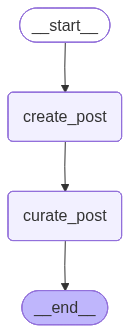

In [5]:
from langgraph.graph import StateGraph, START, END
graph = StateGraph(graph_schema)
#Adding nodes
graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)
#Adding edges
graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)

pydantic_graph = graph.compile()

from IPython.display import Image, display
Image(pydantic_graph.get_graph().draw_mermaid_png())

In [6]:
pydantic_graph.invoke(graph_schema(topic="The importance of data privacy in digital age", 
                                  post="",curated_post=""))

{'topic': 'The importance of data privacy in digital age',
 'post': 'Here\'s a curated post on \'The importance of data privacy in the digital age,\' designed to be informative, engaging, and actionable for a broad audience.\n\n---\n\n## Beyond the Click: The Indispensable Imperative of Data Privacy in the Digital Age\n\nIn a world increasingly defined by ones and zeros, our lives are intrinsically woven into the digital fabric. From online shopping and social media to smart home devices and fitness trackers, every interaction leaves a digital footprint. While this digital evolution offers unprecedented convenience and connection, it also ushers in a critical challenge: **the protection of our personal data.**\n\nData privacy isn\'t just a buzzword; it\'s a fundamental right and an indispensable imperative in today\'s digital landscape.\n\n### The Double-Edged Sword of Data\n\nEvery click, like, search, and purchase contributes to a vast ocean of data about you. Companies collect this 